# WHOOP Next Day Recovery Score Predictor

### Project Aims
Develop a tool to predict a users recovery score for tomorrow morning based on todays recorded data and user inputted sleep metrics.

### Requirements
#### Features:
##### Available in the database
- Today's recovery score
- Today's Strain
- Yesterdays Strain
- 7 Day Rolling strain, HRV, Resting Heart rate etc
- Sleep Debt
- Day of Week
- Sleep Onset Avg (last 4 days?)
- Sleep End (last 4 days?) 

##### Data to be user inputted
- Sleep Onset Tonight
- Sleep End Tomorrow

##### Engineered Feature
- Total Sleep Time Tonight
- Sleep Debt Tomorrow
- Sleep Consistency Tonight

#### Target
- Recovery Score Tomorrow


# WHOOP Recovery Score - Exploratory Data Analysis

# 1.1 Environment Setup

In [1]:
import pandas as pd 
import numpy as np 
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
import seaborn as sns
import matplotlib.pyplot as plt 
import time
from dotenv import load_dotenv
import os
import math

# 2.1 Database Connection to Supabase



In [2]:
load_dotenv(dotenv_path="../.env")

USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DBNAME = os.getenv("DB_NAME")

# Construct the SQLAlchemy connection string
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# Test the connection
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")



Connection successful!


# 2.2 Data Retrieval with SQL

In [3]:

query = text(
    """SELECT 
        -- identifiers
        R.cycle_id
        , R.created_at::date  AS date

        -- recovery score
        , R.recovery_score

        -- physiological signals
        , R.resting_heart_rate
        , R.hrv_rmssd_milli
        , R.spo2_percentage
        , R.skin_temp_celsius

        -- sleep timing
        , S.start AS sleep_start
        , S.end AS sleep_end

        -- raw sleep stage millis (convert to hours in Python)
        , S.total_in_bed_time_milli
        , S.total_awake_time_milli
        , S.total_light_sleep_time_milli
        , S.total_slow_wave_sleep_time_milli
        , S.total_rem_sleep_time_milli

        -- sleep quality metrics
        , S.sleep_efficiency_percentage
        , S.sleep_consistency_percentage
        , S.sleep_performance_percentage
        , S.respiratory_rate
        , S.sleep_cycle_count
        , S.disturbance_count

        -- sleep debt
        , S.sleep_needed_baseline_milli
        , S.sleep_needed_need_from_recent_strain_milli

        -- daily strain
        , C.strain AS cycle_strain
        , C.average_heart_rate AS cycle_avg_heart_rate
        , C.max_heart_rate AS cycle_max_heart_rate
        , C.kilojoule AS cycle_kilojoule

    FROM 
        fact_recovery R
    LEFT JOIN 
        fact_activity_sleep S 
        ON R.sleep_id = S.sleep_id
    LEFT JOIN 
        fact_cycle C 
        ON R.cycle_id = C.cycle_id

    WHERE 
        1=1
        AND S.nap = FALSE
        AND S.total_no_data_time_milli < 0.1

    ORDER BY R.created_at ASC
        """)

df = pd.read_sql_query(query, con=engine)
df.head()

,cycle_id,date,recovery_score,resting_heart_rate,hrv_rmssd_milli,spo2_percentage,skin_temp_celsius,sleep_start,sleep_end,total_in_bed_time_milli,...,sleep_performance_percentage,respiratory_rate,sleep_cycle_count,disturbance_count,sleep_needed_baseline_milli,sleep_needed_need_from_recent_strain_milli,cycle_strain,cycle_avg_heart_rate,cycle_max_heart_rate,cycle_kilojoule
0,485128018,2024-01-01,39,63,55.290910,96.15385,35.300000,2024-01-01 01:29:28.064,2024-01-01 06:25:33.135,17764110,...,54.0,13.437500,3,8,27915179,534836,14.368253,78,186,11146.555
1,485691691,2024-01-02,63,60,63.988388,96.50000,NaN,2024-01-01 23:23:56.167,2024-01-02 05:29:42.835,21945707,...,61.0,13.828125,4,11,27915179,1960856,12.028449,79,185,10150.765
2,486293849,2024-01-03,52,62,55.371407,94.79412,34.600000,2024-01-02 22:53:21.257,2024-01-03 05:37:35.250,24253031,...,65.0,13.857422,5,9,27914873,1190903,5.601850,72,143,8887.534
3,486924019,2024-01-04,59,60,59.133987,95.75000,35.100000,2024-01-03 23:30:49.228,2024-01-04 07:34:50.589,29040400,...,78.0,13.535156,6,16,27914568,226990,12.666767,75,179,10591.021
4,487510229,2024-01-05,73,60,64.707344,95.37500,35.113335,2024-01-04 22:39:14.320,2024-01-05 07:29:53.066,31318679,...,83.0,13.525391,8,17,27914263,1375608,4.392954,69,130,8900.495


## 3 Data Wrangling & Feature Engineering

- Conversion of millisecond columns into minute columns for improved interprability
- Column selection for the dataset
- Handling of Nulls
- Creation of Lag and Shifted features

In [4]:
# Convert the millisecond columns into minutes for bettet interpretability and visualization in Python. 

df_wrangled = df.copy()
milli_cols = ['total_in_bed_time_milli',
               'total_awake_time_milli',
               'total_light_sleep_time_milli',
               'total_slow_wave_sleep_time_milli',
               'total_rem_sleep_time_milli',
               'sleep_needed_need_from_recent_strain_milli',
               'sleep_needed_baseline_milli'
               
               ]
for col in milli_cols:
    df_wrangled[col.replace('_milli', '_hours')] = df_wrangled[col] / 3600000

df_wrangled =df_wrangled.drop(columns=milli_cols)

df_wrangled['total_sleep_time_hours'] = df_wrangled['total_light_sleep_time_hours'] 
+ df_wrangled['total_slow_wave_sleep_time_hours'] 
+ df_wrangled['total_rem_sleep_time_hours']


cols = [
    # identifiers
    'cycle_id',
    'date',

    # recovery score
    'recovery_score',
    
    # physiological metrics
    'hrv_rmssd_milli',
    'resting_heart_rate',
    'spo2_percentage',
    'skin_temp_celsius',
    'respiratory_rate',
    
    # sleep duration
    'total_in_bed_time_hours',
    'total_awake_time_hours',
    
    # sleep stages (minutes)
    'total_light_sleep_time_hours',
    'total_slow_wave_sleep_time_hours',
    'total_rem_sleep_time_hours',
    'total_sleep_time_hours',
    
    # sleep quality
    'sleep_efficiency_percentage',
    'sleep_consistency_percentage',
    'sleep_performance_percentage',
    'sleep_cycle_count',
    'disturbance_count',
    
    # sleep timing
    'sleep_start',
    'sleep_end',
    
    # sleep debt
    'sleep_needed_baseline_hours',
    'sleep_needed_need_from_recent_strain_hours',
    
    # strain
    'cycle_strain',
    'cycle_avg_heart_rate',
    'cycle_max_heart_rate',
    'cycle_kilojoule',
]

df_wrangled = df_wrangled[cols]

df_wrangled.head()

,cycle_id,date,recovery_score,hrv_rmssd_milli,resting_heart_rate,spo2_percentage,skin_temp_celsius,respiratory_rate,total_in_bed_time_hours,total_awake_time_hours,...,sleep_cycle_count,disturbance_count,sleep_start,sleep_end,sleep_needed_baseline_hours,sleep_needed_need_from_recent_strain_hours,cycle_strain,cycle_avg_heart_rate,cycle_max_heart_rate,cycle_kilojoule
0,485128018,2024-01-01,39,55.290910,63,96.15385,35.300000,13.437500,4.934475,0.376511,...,3,8,2024-01-01 01:29:28.064,2024-01-01 06:25:33.135,7.754216,0.148566,14.368253,78,186,11146.555
1,485691691,2024-01-02,63,63.988388,60,96.50000,NaN,13.828125,6.096030,0.825116,...,4,11,2024-01-01 23:23:56.167,2024-01-02 05:29:42.835,7.754216,0.544682,12.028449,79,185,10150.765
2,486293849,2024-01-03,52,55.371407,62,94.79412,34.600000,13.857422,6.736953,0.368507,...,5,9,2024-01-02 22:53:21.257,2024-01-03 05:37:35.250,7.754131,0.330806,5.601850,72,143,8887.534
3,486924019,2024-01-04,59,59.133987,60,95.75000,35.100000,13.535156,8.066778,0.672917,...,6,16,2024-01-03 23:30:49.228,2024-01-04 07:34:50.589,7.754047,0.063053,12.666767,75,179,10591.021
4,487510229,2024-01-05,73,64.707344,60,95.37500,35.113335,13.525391,8.699633,0.825126,...,8,17,2024-01-04 22:39:14.320,2024-01-05 07:29:53.066,7.753962,0.382113,4.392954,69,130,8900.495


In [5]:
# Convert the millisecond columns into minutes for bettet interpretability and visualization in Python. 

df_wrangled = df.copy()
milli_cols = ['total_in_bed_time_milli',
               'total_awake_time_milli',
               'total_light_sleep_time_milli',
               'total_slow_wave_sleep_time_milli',
               'total_rem_sleep_time_milli',
               'sleep_needed_need_from_recent_strain_milli',
               'sleep_needed_baseline_milli'
               
               ]
for col in milli_cols:
    df_wrangled[col.replace('_milli', '_hours')] = df_wrangled[col] / 3600000

df_wrangled =df_wrangled.drop(columns=milli_cols)

df_wrangled['total_sleep_time_hours'] = df_wrangled['total_light_sleep_time_hours'] 
+ df_wrangled['total_slow_wave_sleep_time_hours'] 
+ df_wrangled['total_rem_sleep_time_hours']


cols = [
    # identifiers
    'cycle_id',
    'date',

    # recovery score
    'recovery_score',
    
    # physiological metrics
    'hrv_rmssd_milli',
    'resting_heart_rate',
    'spo2_percentage',
    'skin_temp_celsius',
    'respiratory_rate',
    
    # sleep duration
    'total_in_bed_time_hours',
    'total_awake_time_hours',
    
    # sleep stages (minutes)
    'total_light_sleep_time_hours',
    'total_slow_wave_sleep_time_hours',
    'total_rem_sleep_time_hours',
    'total_sleep_time_hours',
    
    # sleep quality
    'sleep_efficiency_percentage',
    'sleep_consistency_percentage',
    'sleep_performance_percentage',
    'sleep_cycle_count',
    'disturbance_count',
    
    # sleep timing
    'sleep_start',
    'sleep_end',
    
    # sleep debt
    'sleep_needed_baseline_hours',
    'sleep_needed_need_from_recent_strain_hours',
    
    # strain
    'cycle_strain',
    'cycle_avg_heart_rate',
    'cycle_max_heart_rate',
    'cycle_kilojoule',
]

df_wrangled = df_wrangled[cols]

df_wrangled.head()
df_wrangled.describe().T

,count,mean,min,25%,50%,75%,max,std
cycle_id,832.0,861844617.271635,485128018.0,624757184.75,813538831.0,1075116608.75,1441647069.0,270354118.757656
recovery_score,832.0,60.27524,1.0,47.0,62.0,75.0,98.0,20.306969
hrv_rmssd_milli,832.0,66.302368,16.728266,58.343412,67.376565,75.543155,105.77171,14.102092
resting_heart_rate,832.0,59.417067,51.0,56.0,58.0,61.0,86.0,5.137844
spo2_percentage,830.0,96.285328,92.57143,95.71429,96.339743,96.943625,98.85714,0.989051
skin_temp_celsius,822.0,34.954074,33.105,34.752667,35.0,35.2,35.9,0.347579
respiratory_rate,832.0,13.523249,12.30957,13.242188,13.476562,13.710938,16.289062,0.443998
total_in_bed_time_hours,832.0,7.369933,3.103082,6.490382,7.241685,8.175139,11.984278,1.23783
total_awake_time_hours,832.0,0.67524,0.058333,0.456623,0.617515,0.819231,2.656838,0.326589
total_light_sleep_time_hours,832.0,3.045644,1.265475,2.403276,2.97747,3.574664,6.316162,0.835293


In [6]:
## The above describe finds 2 values are missing for spo2_percentage and skin_temp_celsius.

print(f"Nulls in df_wrangled: {df_wrangled['spo2_percentage'].isnull().sum()}")

# Find which rows are null
df_wrangled[df_wrangled['spo2_percentage'].isnull()][['date', 'recovery_score', 'spo2_percentage']]

# Infill with the median for these 2 valus

df_wrangled['spo2_percentage'] = df_wrangled['spo2_percentage'].fillna(df_wrangled['spo2_percentage'].median())

## Skin temp has 10 missing values

Nulls in df_wrangled: 2


In [7]:
## Skin temp has 10 missing values, we will handle this in the same way
# Find which rows are null

print(f"Nulls in df_wrangled: {df_wrangled['skin_temp_celsius'].isnull().sum()}")

df_wrangled[df_wrangled['skin_temp_celsius'].isnull()][['date', 'recovery_score', 'skin_temp_celsius']]

df_wrangled['skin_temp_celsius'] = df_wrangled['skin_temp_celsius'].fillna(df_wrangled['skin_temp_celsius'].median())

Nulls in df_wrangled: 10


# 3.1.2 Feature Engineering
- Lag Recovery (Shifted back by 1 day to align previous day metrics with next day recovery)
- Previous Day strain score as exercise can impact recovery for up to 48 hours
- Creation of 7 day average columns

In [8]:
## Rolling 7 day averages

cols = ['hrv_rmssd_milli',
        'resting_heart_rate',
        'cycle_strain',
]

for col in cols:
    df_wrangled[f'{col}_7d_avg'] = df_wrangled[col].rolling(window=7, min_periods=3).mean()

df_wrangled.describe().T

,count,mean,min,25%,50%,75%,max,std
cycle_id,832.0,861844617.271635,485128018.0,624757184.75,813538831.0,1075116608.75,1441647069.0,270354118.757656
recovery_score,832.0,60.27524,1.0,47.0,62.0,75.0,98.0,20.306969
hrv_rmssd_milli,832.0,66.302368,16.728266,58.343412,67.376565,75.543155,105.77171,14.102092
resting_heart_rate,832.0,59.417067,51.0,56.0,58.0,61.0,86.0,5.137844
spo2_percentage,832.0,96.285459,92.57143,95.71429,96.339743,96.941995,98.85714,0.987864
skin_temp_celsius,832.0,34.954626,33.105,34.768544,35.0,35.2,35.9,0.345518
respiratory_rate,832.0,13.523249,12.30957,13.242188,13.476562,13.710938,16.289062,0.443998
total_in_bed_time_hours,832.0,7.369933,3.103082,6.490382,7.241685,8.175139,11.984278,1.23783
total_awake_time_hours,832.0,0.67524,0.058333,0.456623,0.617515,0.819231,2.656838,0.326589
total_light_sleep_time_hours,832.0,3.045644,1.265475,2.403276,2.97747,3.574664,6.316162,0.835293


In [9]:
df_wrangled['shifted_recovery_score'] = df_wrangled['recovery_score'].shift(1)

In [10]:
df_wrangled['previous_day_strain'] = df_wrangled['cycle_strain'].shift(1)

## Rolling 7 day averages

cols = ['hrv_rmssd_milli',
        'resting_heart_rate',
        'cycle_strain',
]

for col in cols:
    df_wrangled[f'{col}_7d_avg'] = df_wrangled[col].rolling(window=7, min_periods=3).mean()

df_wrangled.describe().T

,count,mean,min,25%,50%,75%,max,std
cycle_id,832.0,861844617.271635,485128018.0,624757184.75,813538831.0,1075116608.75,1441647069.0,270354118.757656
recovery_score,832.0,60.27524,1.0,47.0,62.0,75.0,98.0,20.306969
hrv_rmssd_milli,832.0,66.302368,16.728266,58.343412,67.376565,75.543155,105.77171,14.102092
resting_heart_rate,832.0,59.417067,51.0,56.0,58.0,61.0,86.0,5.137844
spo2_percentage,832.0,96.285459,92.57143,95.71429,96.339743,96.941995,98.85714,0.987864
skin_temp_celsius,832.0,34.954626,33.105,34.768544,35.0,35.2,35.9,0.345518
respiratory_rate,832.0,13.523249,12.30957,13.242188,13.476562,13.710938,16.289062,0.443998
total_in_bed_time_hours,832.0,7.369933,3.103082,6.490382,7.241685,8.175139,11.984278,1.23783
total_awake_time_hours,832.0,0.67524,0.058333,0.456623,0.617515,0.819231,2.656838,0.326589
total_light_sleep_time_hours,832.0,3.045644,1.265475,2.403276,2.97747,3.574664,6.316162,0.835293


# 4. Exploratory Data Analysis

## 4.1 Data Distribution

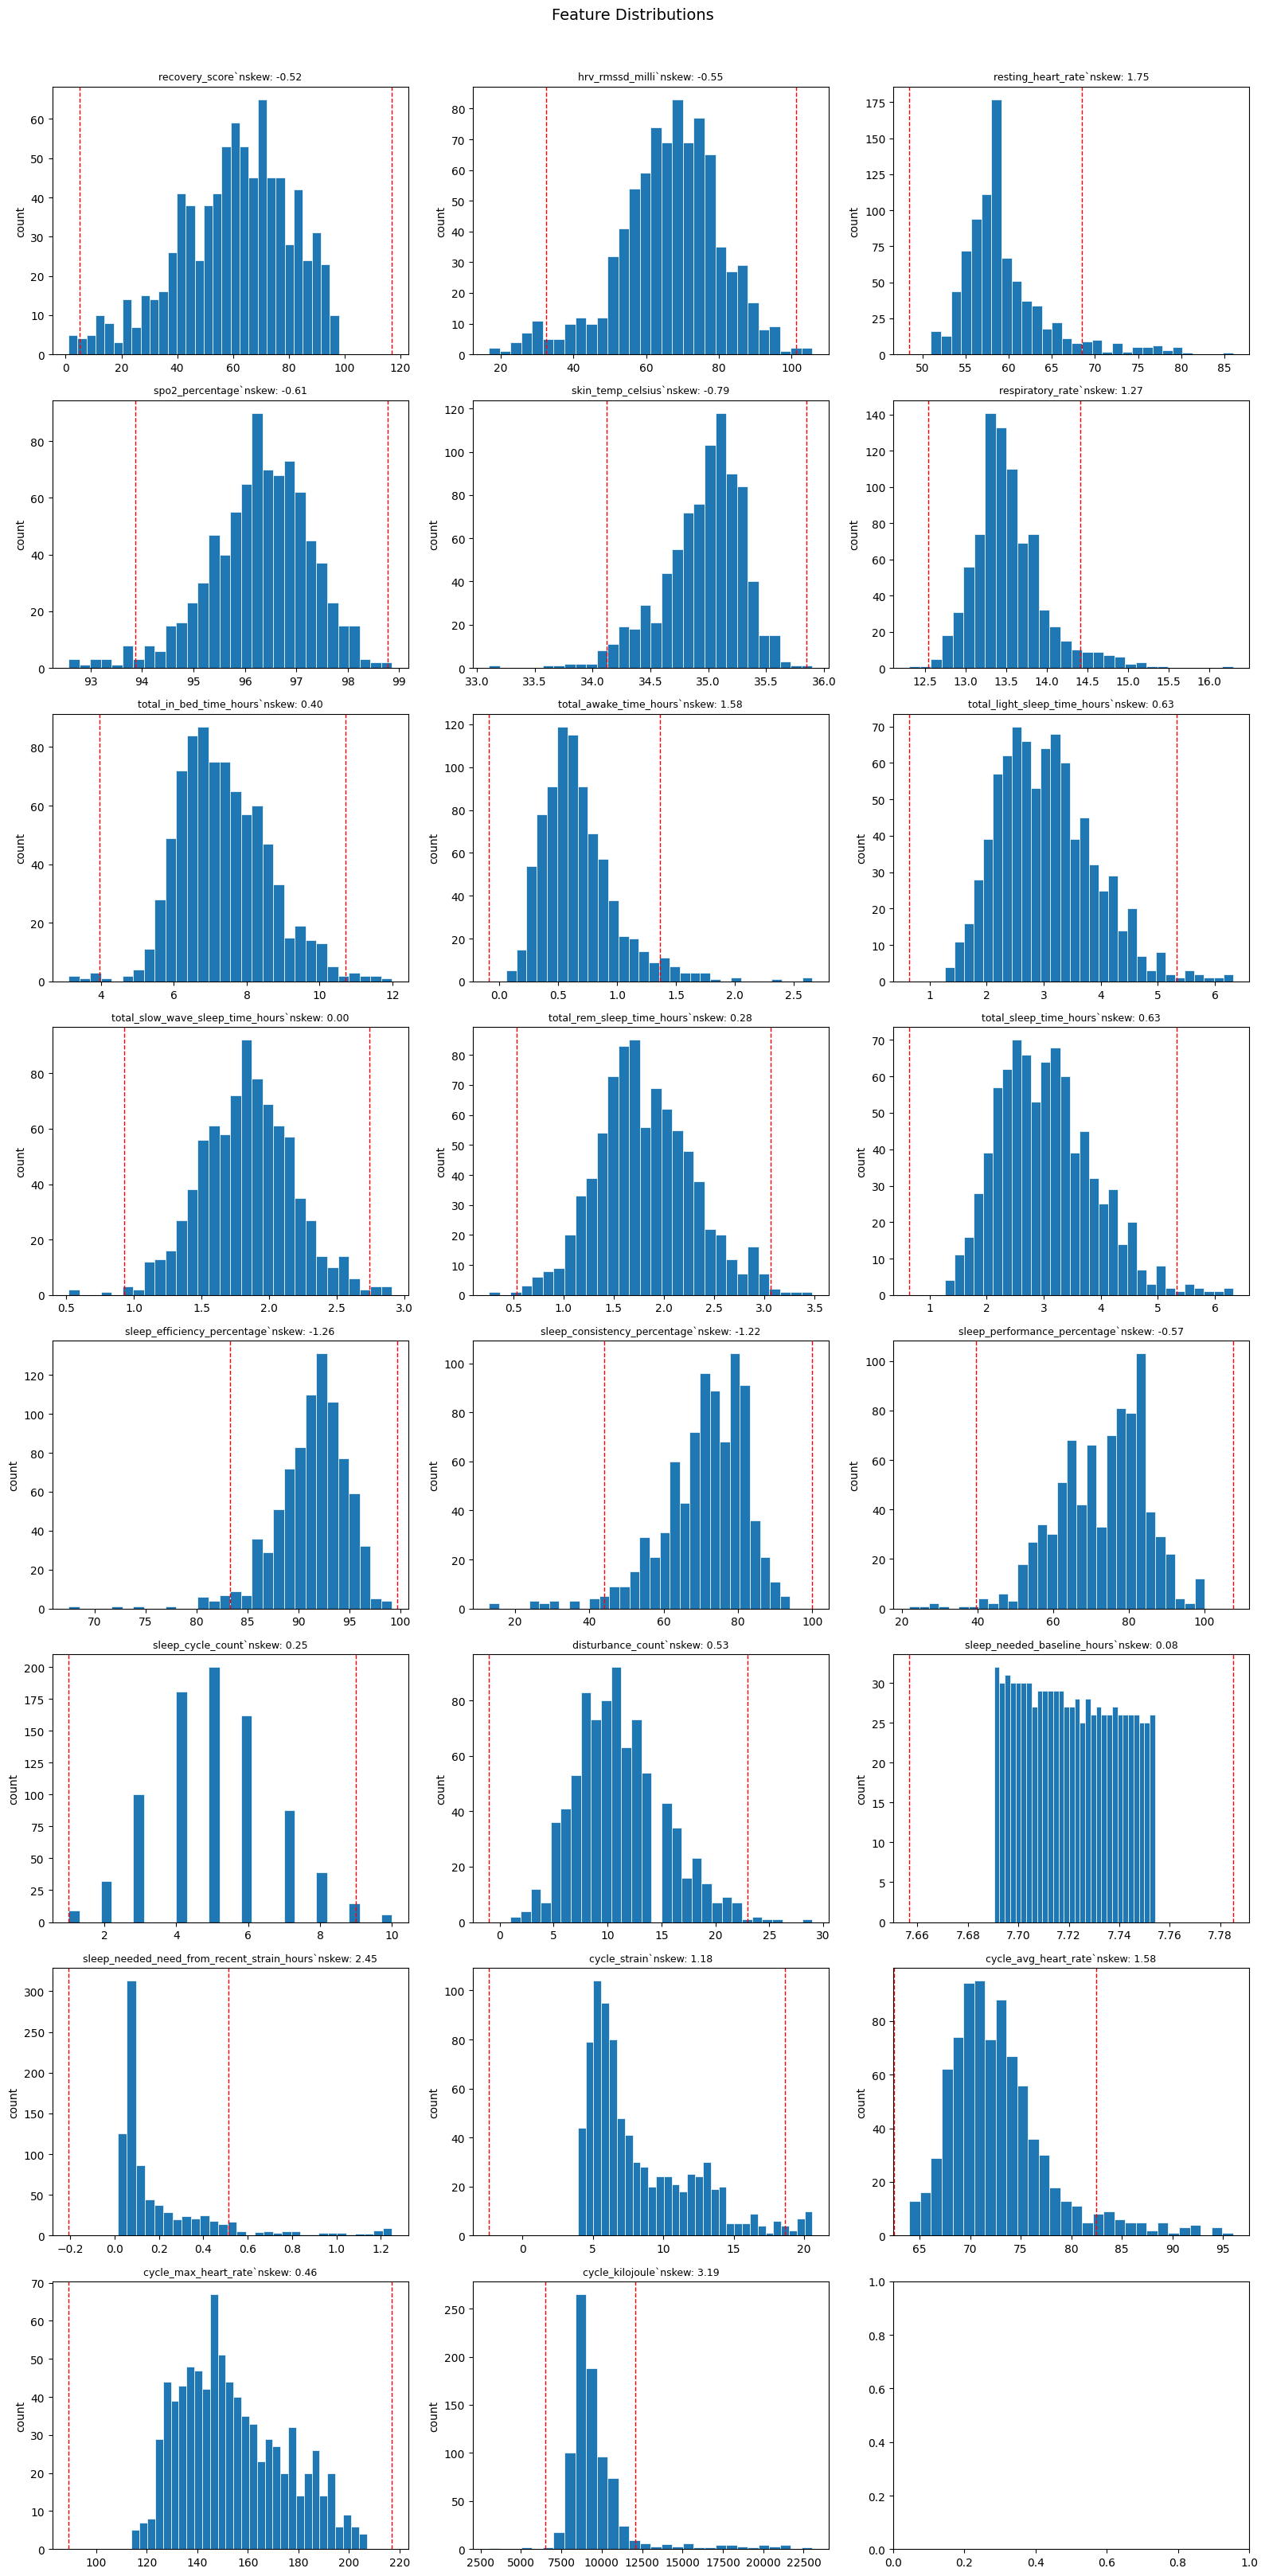

In [11]:
cols_distribution = [
    'recovery_score',
    
    # physiological metrics
    'hrv_rmssd_milli',
    'resting_heart_rate',
    'spo2_percentage',
    'skin_temp_celsius',
    'respiratory_rate',
    
    # sleep duration
    'total_in_bed_time_hours',
    'total_awake_time_hours',
    
    # sleep stages (minutes)
    'total_light_sleep_time_hours',
    'total_slow_wave_sleep_time_hours',
    'total_rem_sleep_time_hours',
    'total_sleep_time_hours',
    
    # sleep quality
    'sleep_efficiency_percentage',
    'sleep_consistency_percentage',
    'sleep_performance_percentage',
    'sleep_cycle_count',
    'disturbance_count',
    
    # sleep debt
    'sleep_needed_baseline_hours',
    'sleep_needed_need_from_recent_strain_hours',
    
    # strain
    'cycle_strain',
    'cycle_avg_heart_rate',
    'cycle_max_heart_rate',
    'cycle_kilojoule',
]

n_cols = 3
n_rows = math.ceil(len(cols_distribution) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_distribution):
    axes[i].hist(df_wrangled[col].dropna(), bins=30, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')

    quartile_1 = df_wrangled[col].quantile(0.25)
    quartile_3 = df_wrangled[col].quantile(0.75)
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - 1.5 * iqr
    upper_bound = quartile_3 + 1.5 * iqr
    axes[i].axvline(lower_bound, color='red', linestyle='--', linewidth=1, label='lower bound')
    axes[i].axvline(upper_bound, color='red', linestyle='--', linewidth=1, label='upper bound')

    skew = df_wrangled[col].skew()
    axes[i].set_title(f'{col}`nskew: {skew:.2f}', fontsize = 9)


plt.suptitle('Feature Distributions', fontsize = 14, y=1.01)
plt.tight_layout()
plt.show()

## 4.1.1 Observations from Facet Distribution Grid

the outliers for recovery and hrv are on the lower bound and very likely caused by alcohol consumption in combination with high physical activity (after playing cricket the day prior). These would likely provide noise within the model but will likely occur again in the furute, consider whether these should be included. An alcohol consumption flag could be added for outliers in both hrv and recovery score columns.

Low spo2 is likely through periods of illness and again, without logged data to support whether I was feeling ill, these should be treat with caution and removed from the analyses

Several metrics are positively skewed, with the primary candiate being sleep needed from recent strain with a score of 2.5. Considerations to log transform this metric should it be included within the model would be prudent

In [12]:
# Count of outliers in reovery and hrv based on iqr. IQR used as less sensitive to data distribution than z scores

q1_recovery = df_wrangled['recovery_score'].quantile(0.25)
iqr_recovery = df_wrangled['recovery_score'].quantile(0.75) - q1_recovery

lower_bound_recovery = q1_recovery - (iqr_recovery * 1.5)
print(f'lower bound recovery score: {lower_bound_recovery:.2f}')
upper_bound_recovery = q1_recovery + (iqr * 1.5)

lower_bound_outliers_recovery = df_wrangled[df_wrangled['recovery_score'] < lower_bound_recovery]

print(f'Number of outliers lower bound: {len(lower_bound_outliers_recovery)/ len(df_wrangled["recovery_score"]):.2%} ')

# HRV outliers
q1_hrv = df_wrangled['hrv_rmssd_milli'].quantile(0.25)
iqr_hrv = df_wrangled['hrv_rmssd_milli'].quantile(0.75) - q1_hrv

lower_bound_hrv = q1_hrv - (iqr_hrv * 1.5)
print(f'lower bound hrv score: {lower_bound_hrv:.2f}')

lower_bound_outliers_hrv = df_wrangled[df_wrangled['hrv_rmssd_milli'] < lower_bound_hrv]

print(f'Number of outliers lower bound: {len(lower_bound_outliers_hrv)/ len(df_wrangled["hrv_rmssd_milli"]):.2%} ')

lower_bound_outliers_hrv_recovery = df_wrangled[(df_wrangled['recovery_score'] < lower_bound_recovery) & (df_wrangled['hrv_rmssd_milli'] < lower_bound_hrv)]
print(f'Number of outliers lower bound: {len(lower_bound_outliers_hrv_recovery)} ')

lower bound recovery score: 5.00
Number of outliers lower bound: 0.60% 
lower bound hrv score: 32.54
Number of outliers lower bound: 3.00% 
Number of outliers lower bound: 4 


# 4.1.2 Observations on outlier counts
Using the IQR is a very low threshold for both and likely a less than 5% recovery is much lower than most days following high strain and alcohol consumption.

Research provides detail of HRV decreasing by 28-33% in healthy subjects (Spaak et al 2010) with there being no protection for those that are physically active (Ralevski et al 2019).

Taking in the 28 - 33% decrease fromn the mean a threshold can be applied for low hrv days potentially caused by alochol and this can be used as a flag in combination with a low recovery score (< 34 red recovery in Whoop Scores)



In [13]:
hrv_median = df_wrangled['hrv_rmssd_milli'].median() # median is more robust to the outliers we know are present
low_hrv_threshold = hrv_median * 0.67 # more conservative requiring the larger decrease based on the study of 33% decrease 

print(low_hrv_threshold)

df_wrangled['alcohol_consumed_flag'] = ((df_wrangled['recovery_score'] < 34) & (df_wrangled['hrv_rmssd_milli'] < low_hrv_threshold)).astype(int)

df_wrangled[df_wrangled['alcohol_consumed_flag'] == 1].head()


45.14229855


,cycle_id,date,recovery_score,hrv_rmssd_milli,resting_heart_rate,spo2_percentage,skin_temp_celsius,respiratory_rate,total_in_bed_time_hours,total_awake_time_hours,...,cycle_strain,cycle_avg_heart_rate,cycle_max_heart_rate,cycle_kilojoule,hrv_rmssd_milli_7d_avg,resting_heart_rate_7d_avg,cycle_strain_7d_avg,shifted_recovery_score,previous_day_strain,alcohol_consumed_flag
27,501479471,2024-01-28,8,29.129147,79,94.17647,34.731667,15.263672,6.656830,0.472643,...,9.569801,84,136,9487.1060,61.603855,63.142857,9.982594,12.0,16.571379,1
33,505803494,2024-02-04,29,40.553030,72,97.17647,35.400000,14.033203,6.560704,0.488670,...,5.224786,76,134,7748.6265,65.949668,64.000000,8.232678,75.0,13.089346,1
58,521515146,2024-02-29,10,30.013900,76,96.18750,35.000000,13.769531,7.562068,0.720984,...,13.369027,90,132,11972.9030,71.100340,59.714286,9.645574,38.0,6.930608,1
59,522245741,2024-03-01,14,29.114288,78,95.50000,35.100000,13.945312,6.240274,0.280381,...,5.344415,76,127,7591.3120,63.743567,63.000000,8.319720,10.0,13.369027,1
90,542180318,2024-04-01,17,43.392506,69,96.50000,35.036667,14.326172,7.522024,0.520718,...,12.057415,77,171,10655.5040,76.294229,57.142857,9.118869,52.0,4.641273,1


# 4.2 Time Series analysis
Using matplotlibs time series graphs, I am looking for any seasonal trends in behaviour for metrics such as recovery scores, 

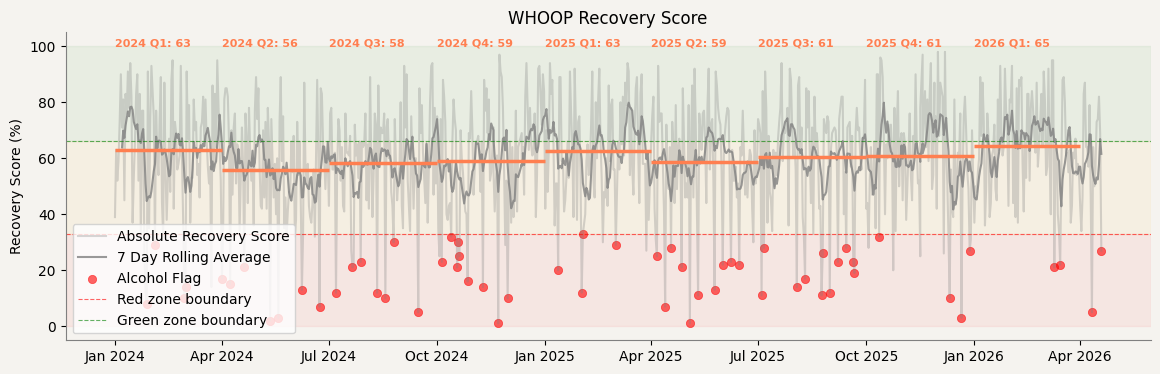

In [14]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#f5f3ef') 
ax.set_facecolor('#f5f3ef')

df_visual = df_wrangled.copy()
ax.plot(df_visual['date'], df_visual['recovery_score'], label='Absolute Recovery Score', color='gray', alpha=0.3)
ax.plot(df_visual['date'], df_visual['recovery_score'].rolling(7).mean(), label='7 Day Rolling Average', color='gray', alpha=0.8)

alcohol = df_visual[df_visual['alcohol_consumed_flag'] == 1]
ax.scatter(alcohol['date'], alcohol['recovery_score'], color='red', label='Alcohol Flag', alpha=0.6, edgecolors='red', linewidth=0.5)

df_visual['year_quarter'] = pd.to_datetime(df_visual['date']).dt.to_period('Q')

quarterly = (df_visual.groupby('year_quarter')['recovery_score'].agg(avg_recovery='mean', day_count='count').reset_index())

# Drop partial quarters
quarterly = quarterly[quarterly['day_count'] >= 30]

# Convert period to actual dates for plotting
quarterly['quarter_start'] = quarterly['year_quarter'].dt.start_time
quarterly['quarter_end'] = quarterly['year_quarter'].dt.end_time

# Label e.g. "2024 Q1"
quarterly['label'] = quarterly['year_quarter'].dt.strftime('%Y Q') + \
                     quarterly['year_quarter'].dt.quarter.astype(str)

for _ , row in quarterly.iterrows():
    ax.hlines(
        y=row['avg_recovery'],
        xmin=row['quarter_start'],
        xmax=row['quarter_end'],
        color='coral',
        linewidth=2.5,
        zorder=4
    )
    ax.text(
        row['quarter_start'],
        100,
        f"{row['label']}: {row['avg_recovery']:.0f}",
        fontsize=8,
        fontweight='bold',
        color='coral'
    )


ax.axhline(y=33, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='Red zone boundary')
ax.axhline(y=66, color='green', linestyle='--', linewidth=0.8, alpha=0.6, label='Green zone boundary')
ax.axhspan(0, 33, alpha=0.05, color='red')
ax.axhspan(33, 66, alpha=0.05, color='orange')
ax.axhspan(66, 100, alpha=0.05, color='green')
ax.set_ylabel('Recovery Score (%)')
ax.set_title('WHOOP Recovery Score', fontsize=12)

# Axis formatting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.legend(loc='lower left')
plt.show()

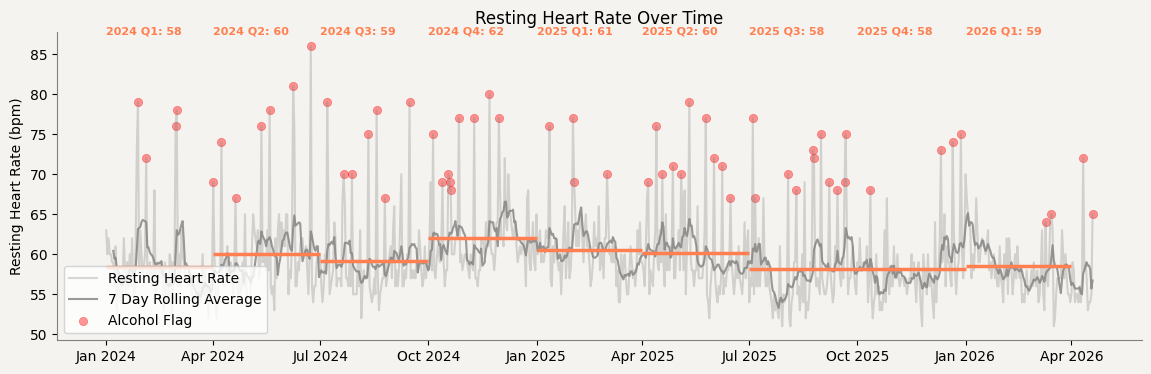

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#f5f3ef') 
ax.set_facecolor('#f5f3ef')

df_visual = df_wrangled.copy()
ax.plot(df_visual['date'], df_visual['resting_heart_rate'], label='Resting Heart Rate', color='gray', alpha=0.3)
ax.plot(df_visual['date'], df_visual['resting_heart_rate'].rolling(7).mean(), label='7 Day Rolling Average', color='gray', alpha=0.8)

alcohol = df_visual[df_visual['alcohol_consumed_flag'] == 1]
ax.scatter(alcohol['date'], alcohol['resting_heart_rate'], color='red', label='Alcohol Flag', alpha=0.4, edgecolors='red', linewidth=0.5)


df_visual['year_quarter'] = pd.to_datetime(df_visual['date']).dt.to_period('Q')

quarterly = (df_visual.groupby('year_quarter')['resting_heart_rate'].agg(avg_recovery='mean', day_count='count').reset_index())

# Drop partial quarters
quarterly = quarterly[quarterly['day_count'] >= 30]

# Convert period to actual dates for plotting
quarterly['quarter_start'] = quarterly['year_quarter'].dt.start_time
quarterly['quarter_end'] = quarterly['year_quarter'].dt.end_time

# Label e.g. "2024 Q1"
quarterly['label'] = quarterly['year_quarter'].dt.strftime('%Y Q') + \
                     quarterly['year_quarter'].dt.quarter.astype(str)


max_rhr = df_visual['resting_heart_rate'].max()
for _, row in quarterly.iterrows():
    ax.hlines(
        y=row['avg_recovery'],
        xmin=row['quarter_start'],
        xmax=row['quarter_end'],
        color='coral',
        linewidth=2.5,
        zorder=4
    )
    ax.text(
        row['quarter_start'],
        max_rhr + 1.5,
        f"{row['label']}: {row['avg_recovery']:.0f}",
        fontsize=8,
        fontweight='bold',
        color='coral'
    )

ax.set_ylabel('Resting Heart Rate (bpm)')
ax.set_title('Resting Heart Rate Over Time', fontsize=12)

# Axis formatting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.legend(loc='lower left')
plt.show()

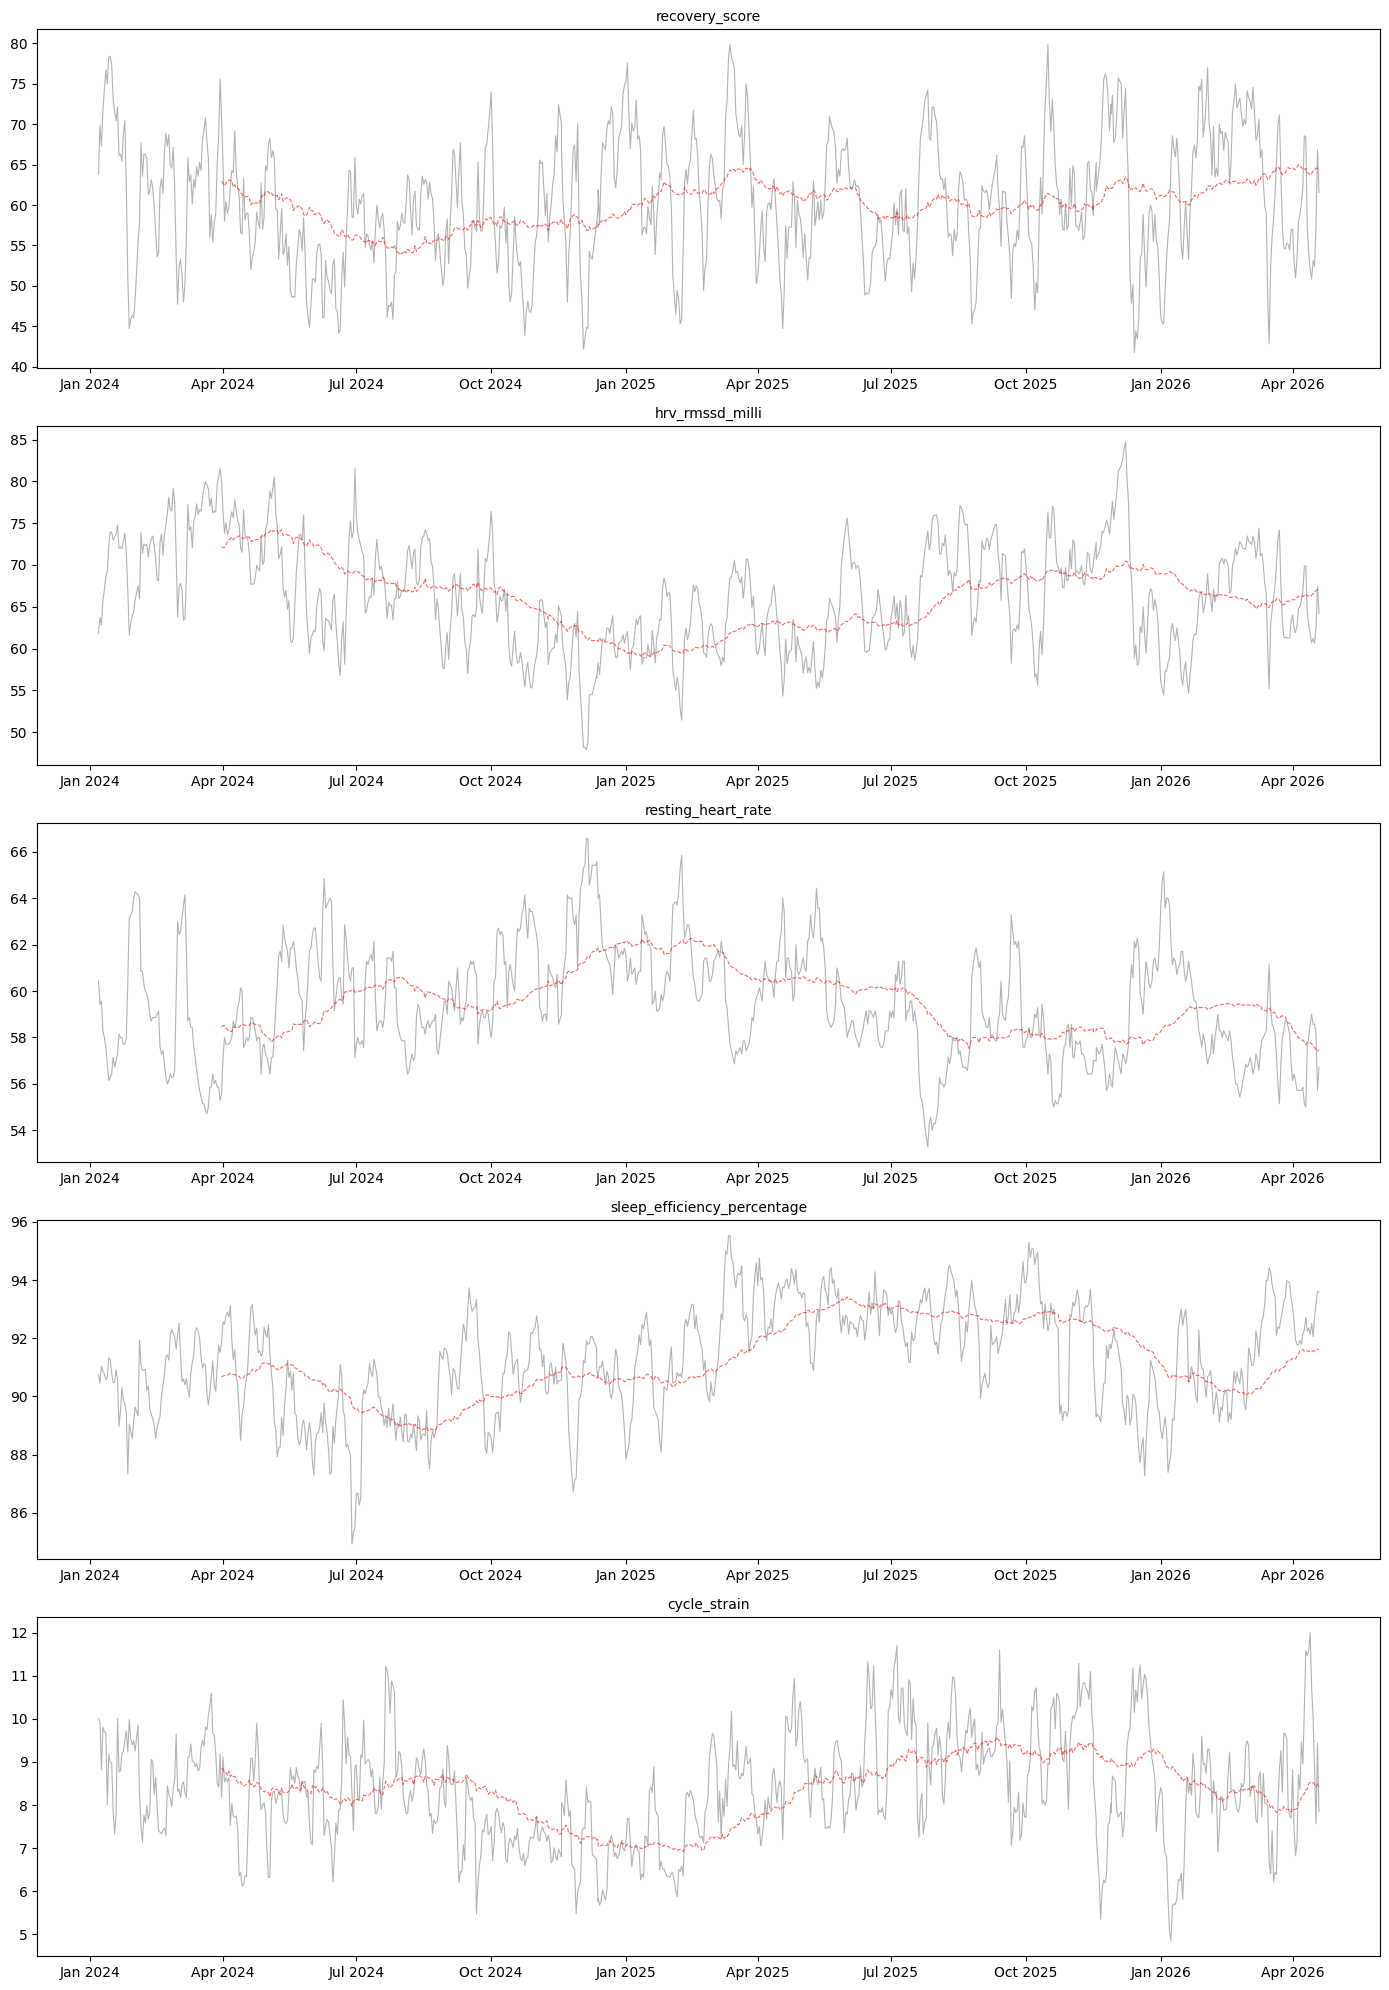

In [16]:
time_series_cols = [
    'recovery_score',
    'hrv_rmssd_milli',
    'resting_heart_rate',
    'sleep_efficiency_percentage',
    'cycle_strain',
]

n_cols = 1
n_rows = len(time_series_cols)
fig,axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

for i, col in enumerate(time_series_cols):
    axes[i].plot(df_wrangled['date'], df_wrangled[col].rolling(7).mean(), color='grey', linestyle='-', linewidth=0.8, alpha=0.6, label='7 Day Rolling')
    axes[i].plot(df_wrangled['date'], df_wrangled[col].rolling(90).mean(), color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='90 Day Rolling')
    axes[i].set_title(col, fontsize = 10)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    

plt.tight_layout()
plt.show()

# 4.3 Temporal Analysis - Investigating day of week and month of year impact
Anecdotally a lot of the high cycle strains will appear on a saturday through cricket season months within the UK (Apr to Sept)

This will also coincide with lower recoveries on a sunday due to the high strain and much higher probability of alcohol consumption

It is also expected that resting heart rate will decrease during summer months as fitness increases during the cricket season

The winter months (excl Dec) are much more likely to see less variance in the results due to reduced alcohol consumption in combination with less extreme values in cycle strain

As for day of weeks, it is expected that recoveries will be lower on Sundays, as well as wednesdays which are caused by increased sleep debt as a result of office days being tuesday and a wednesday. These typically feel to be the hardest days in terms of how the body feels, so it will be interesting to see how this impacts the data

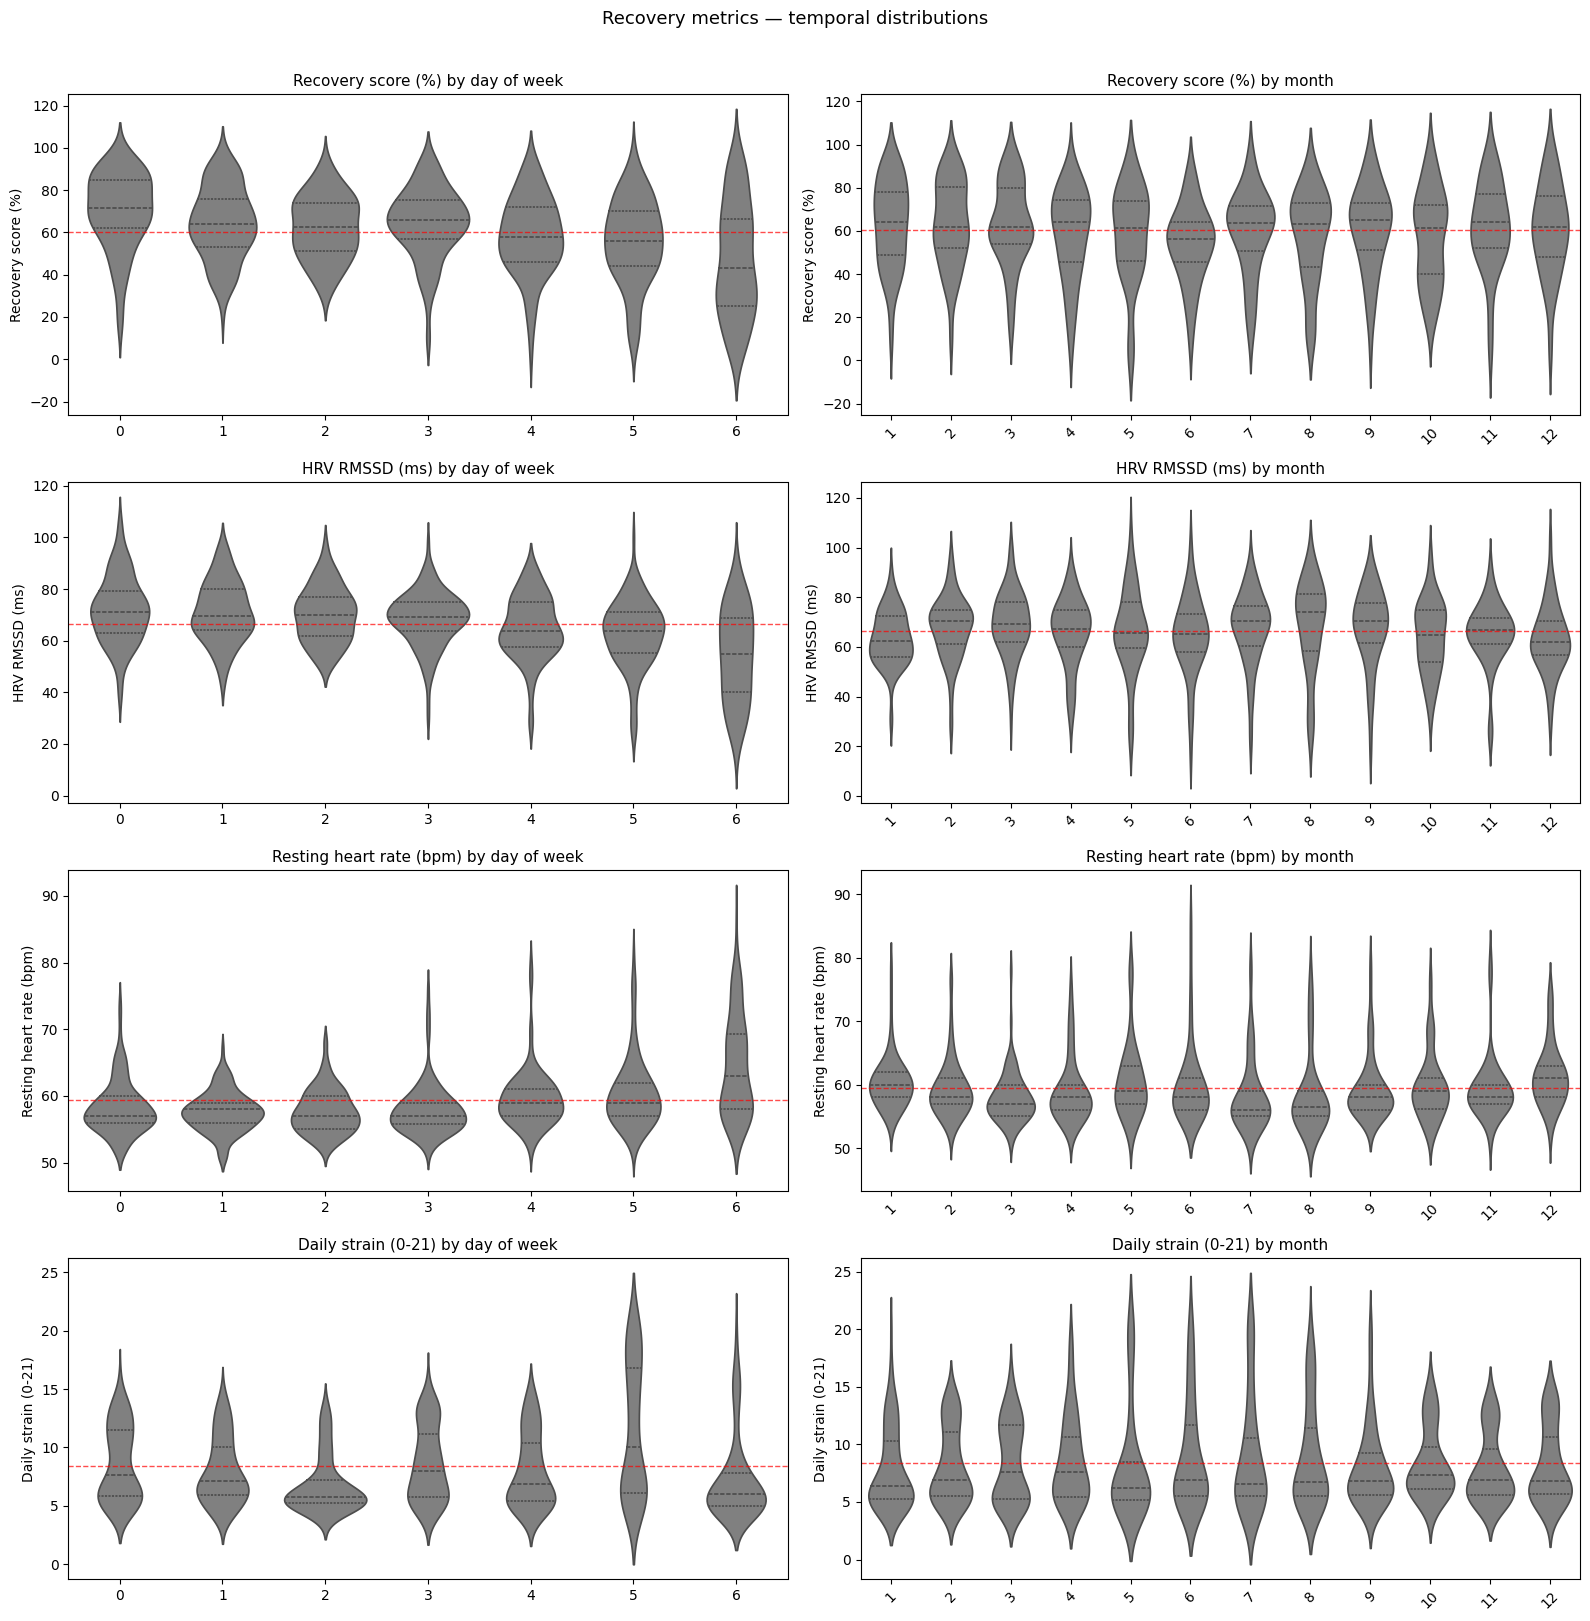

In [17]:
# Ensure day_of_week is extracted
df_visual = df_wrangled.copy()
df_visual['day_of_week'] = pd.to_datetime(df_visual['date']).dt.dayofweek
df_visual['month'] = pd.to_datetime(df_visual['date']).dt.month

day_labels = df_visual['day_of_week'].unique().tolist()
month_labels = df_visual['month'].unique().tolist()


metrics = {
    'recovery_score': 'Recovery score (%)',
    'hrv_rmssd_milli': 'HRV RMSSD (ms)',
    'resting_heart_rate': 'Resting heart rate (bpm)',
    'cycle_strain': 'Daily strain (0-21)'
}

fig, axes = plt.subplots(len(metrics), 2, figsize=(16, len(metrics) * 4))

for i, (col, label) in enumerate(metrics.items()):

    # Day of week violin
    sns.violinplot(
        data=df_visual,
        x='day_of_week',
        y=col,
        ax=axes[i, 0],
        inner='quartile',
        color='gray',
    )
    axes[i, 0].set_xticks(range(7))
    axes[i, 0].set_xticklabels(day_labels)
    axes[i, 0].axhline(df_visual[col].mean(), color='red', 
                        linestyle='--', linewidth=1, alpha=0.7)
    axes[i, 0].set_title(f'{label} by day of week', fontsize=11)
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel(label)

    # Month violin
    sns.violinplot(
        data=df_visual,
        x='month',
        y=col,
        ax=axes[i, 1],
        inner='quartile',
        color='gray',
    )
    axes[i, 1].set_xticks(range(12))
    axes[i, 1].set_xticklabels(df_visual['month'].unique(), rotation=45)
    axes[i, 1].axhline(df_visual[col].mean(), color='red',
                        linestyle='--', linewidth=1, alpha=0.7)
    axes[i, 1].set_title(f'{label} by month', fontsize=11)
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel(label)

plt.suptitle('Recovery metrics — temporal distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 4.3.1 Analysis of DOW & Month 
### Day of Week
Clear Degredation as the week progresses is apparrent in the data with the strongest metrics occuring on monday and the lowest on a sunday, suggesting that physiological health markers follow a day of week pattern, therefore a day of week flag should be included as a feature within the dataset

### Monthly patterns
At a monthly level there are very few emerging patterns, the only. clear observation is a much higher tail of strain scores from april to september which refelects my expectation during cricket season where I know most game days average a strain between 17 and 21. As a result of not many patterns in the monthly data other than this, at this time no month flag will be included as a feature.

In [18]:
## Adding the day of week flag to the df_wrangled dataframe

df_wrangled['day_of_week'] = pd.to_datetime(df_wrangled['date']).dt.dayofweek
df_wrangled.drop(columns=['month'], inplace=True, errors='ignore') # drop month if exists from previous cell run
print(df_wrangled.columns.tolist())

['cycle_id', 'date', 'recovery_score', 'hrv_rmssd_milli', 'resting_heart_rate', 'spo2_percentage', 'skin_temp_celsius', 'respiratory_rate', 'total_in_bed_time_hours', 'total_awake_time_hours', 'total_light_sleep_time_hours', 'total_slow_wave_sleep_time_hours', 'total_rem_sleep_time_hours', 'total_sleep_time_hours', 'sleep_efficiency_percentage', 'sleep_consistency_percentage', 'sleep_performance_percentage', 'sleep_cycle_count', 'disturbance_count', 'sleep_start', 'sleep_end', 'sleep_needed_baseline_hours', 'sleep_needed_need_from_recent_strain_hours', 'cycle_strain', 'cycle_avg_heart_rate', 'cycle_max_heart_rate', 'cycle_kilojoule', 'hrv_rmssd_milli_7d_avg', 'resting_heart_rate_7d_avg', 'cycle_strain_7d_avg', 'shifted_recovery_score', 'previous_day_strain', 'alcohol_consumed_flag', 'day_of_week']


# 4.4 Investigating correlation between metrics

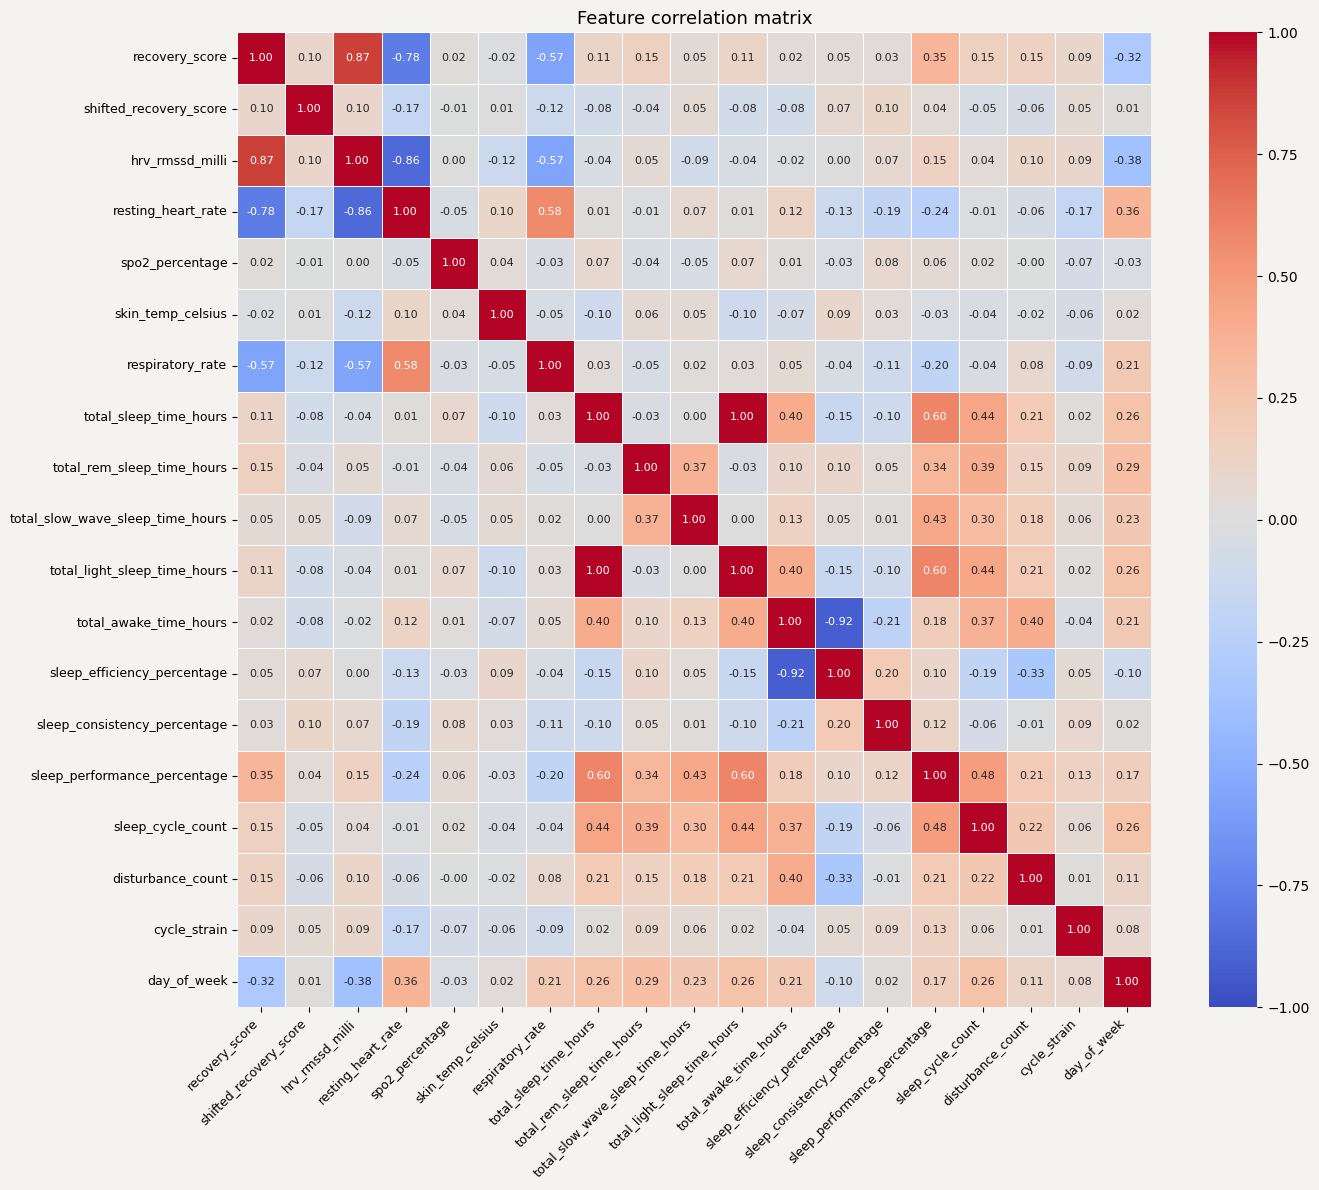

In [19]:
corr_cols = [
    'recovery_score',
    'shifted_recovery_score',
    'hrv_rmssd_milli',
    'resting_heart_rate',
    'spo2_percentage',
    'skin_temp_celsius',
    'respiratory_rate',
    'total_sleep_time_hours',
    'total_rem_sleep_time_hours',
    'total_slow_wave_sleep_time_hours',
    'total_light_sleep_time_hours',
    'total_awake_time_hours',
    'sleep_efficiency_percentage',
    'sleep_consistency_percentage',
    'sleep_performance_percentage',
    'sleep_cycle_count',
    'disturbance_count',
    'cycle_strain',
    'day_of_week',
]

corr_matrix = df_wrangled[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#f5f3ef')
ax.set_facecolor('#f5f3ef')

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('Feature correlation matrix', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## 4.4.2 Correlation matrix — feature screening

Pearson correlation used as an initial screening heuristic (Cohen, 1988). 
No universal threshold exists for ML feature selection — final feature 
elimination decisions are deferred to SHAP analysis post-training, which 
provides empirical, model-based evidence rather than univariate linear 
correlation alone. Pearson correlation also only captures linear 
relationships and may understate predictive value in features with 
non-linear relationships to recovery score.

**Features removed at this stage:**
- `total_light_sleep_time_hours`: perfect multicollinearity with `total_sleep_time_hours` (r=1.00), mathematically redundant

**Features retained despite high inter-feature correlation:**
- `hrv_rmssd_milli` and `resting_heart_rate` (r=-0.86) both show strong independent correlation with recovery score (0.86 and -0.78 respectively) and measure distinct physiological constructs. Retention justified by domain knowledge as HRV reflects parasympathetic activity, RHR reflects overall cardiac load. Will be reviewed post SHAP analysis.

**Features retained despite weak target correlation:**
- `spo2_percentage`, `skin_temp_celsius`, `cycle_strain` weak linear correlation with recovery score but potential non-linear signal

In [20]:
df_wrangled = df_wrangled.drop(columns=['total_light_sleep_time_hours'])

## 5. Key findings — EDA summary

**Target variable:** Recovery score is approximately normally distributed 
(mean 59.7, std 21.1) with full range utilisation (1–98). Well suited 
for regression modelling.

**Strongest predictors identified:**
- HRV RMSSD (r=0.86): strongest single predictor of recovery score
- Resting heart rate (r=-0.78): strong negative relationship
- Respiratory rate (r=-0.57): moderate negative relationship
- Sleep performance percentage (r=0.35): moderate positive relationship

**Temporal patterns:**
- Strong day-of-week effect: Sunday recovery averages 45.9 vs Monday 69.1
- No meaningful monthly seasonality detected: month flag excluded from features
- Weekend suppression likely attributable to social/lifestyle factors

**Multicollinearity:**
- total_light_sleep_time_hours removed (r=1.00 with total_sleep_time_hours)
- HRV and RHR retained despite high inter-feature correlation (r=-0.86) 
  — both show strong independent signal and measure distinct physiology

**Alcohol consumption days:**
- Records flagged as physiologically anomalous using research-backed thresholds (Spaak et al., 2010; WHOOP official red zone definition)
- Retained with binary flag rather than removed — preserves dataset size and useful as this will continue to happen going forward

**Features carried forward to modelling:**
hrv_rmssd_milli, resting_heart_rate, respiratory_rate, total_sleep_hours,
total_rem_sleep_time_hours, total_slow_wave_sleep_time_hours, 
total_awake_time_hours, sleep_performance_percentage, sleep_cycle_count,
disturbance_count, cycle_strain, day_of_week, is_weekend, alcohol_consumed_flag